# 1. Описательный анализ и предобработка датасета

## Описание датасета Laptop Price

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('laptop_price.csv', encoding='latin1')

data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [48]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


## Предобработка набора

In [49]:
import re

data['Ram'] = data['Ram'].str.replace('GB', '').astype(int)
data['Weight'] = data['Weight'].str.replace('kg', '').astype(float)

def parse_cpu_model(text):
    text = re.sub(r'\s*\d+(\.\d+)?\s*ghz', '', text.lower())
    return text.strip().title()

def parse_cpu_ghz(text):

    match = re.search(r'(\d+(\.\d+)?)\s*ghz', text.lower())
    if match:
        return float(match.group(1))
    return None

data['Cpu_GHz'] = data['Cpu'].apply(parse_cpu_ghz)
data['Cpu'] = data['Cpu'].apply(parse_cpu_model)

data[['Cpu', 'Cpu_GHz']].head(10)
def extract_memory_type(mem):
    mem = mem.lower()
    if "ssd" in mem:
        return "SSD"
    if "hdd" in mem:
        return "HDD"
    if "hybrid" in mem:
        return "Hybrid"
    if "flash" in mem:
        return "Flash"
    if "emmc" in mem:
        return "eMMC"
    if "sshd" in mem:
        return "SSHD"
    return "Unknown"

def extract_memory_size(mem):

    parts = mem.split('+')
    total = 0

    for p in parts:
        p = p.strip().lower()

        tb_match = re.search(r'(\d+)\s*tb', p)
        if tb_match:
            total += int(tb_match.group(1)) * 1024
            continue

        gb_match = re.search(r'(\d+)\s*gb', p)
        if gb_match:
            total += int(gb_match.group(1))
            continue

    return total

data['Memory_type'] = data['Memory'].apply(extract_memory_type)

data['Memory'] = data['Memory'].apply(extract_memory_size)


In [50]:
data = data.rename(columns={
    'Ram': 'Ram_GB',
    'Memory': 'Memory_GB',
    'Weight': 'Weight_KG'
})

data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory_GB,Gpu,OpSys,Weight_KG,Price_euros,Cpu_GHz,Memory_type
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core I5,8,128,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2.3,SSD
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core I5,8,128,Intel HD Graphics 6000,macOS,1.34,898.94,1.8,Flash
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core I5 7200U,8,256,Intel HD Graphics 620,No OS,1.86,575.00,2.5,SSD
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core I7,16,512,AMD Radeon Pro 455,macOS,1.83,2537.45,2.7,SSD
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core I5,8,256,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,3.1,SSD


## Распределения числовых показателей

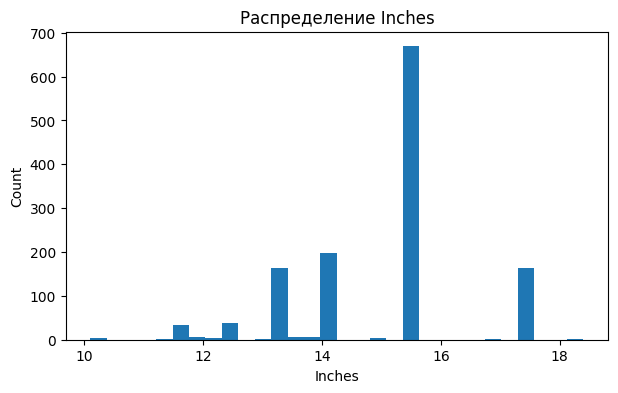

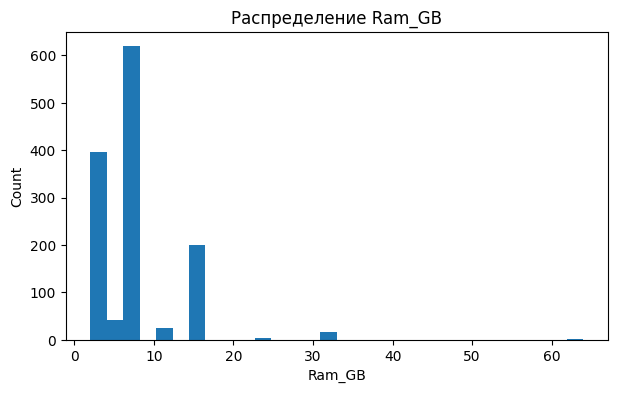

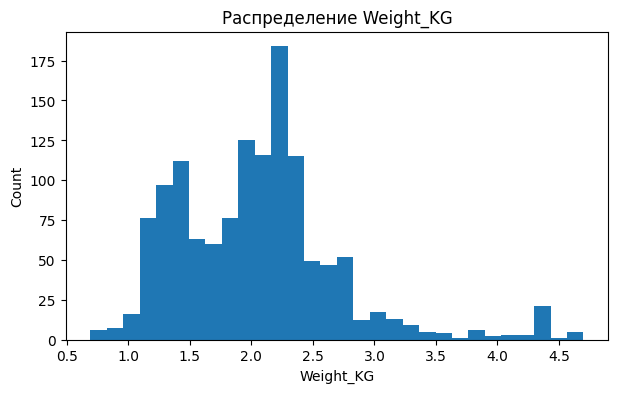

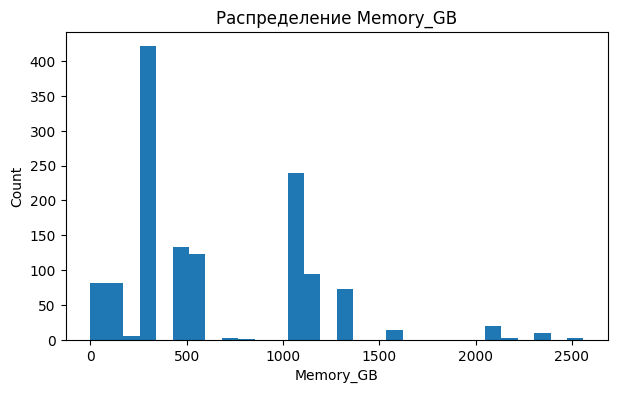

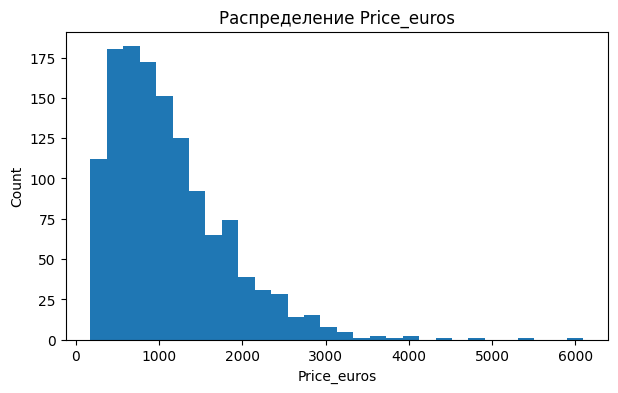

In [51]:
numeric_cols = ['Inches', 'Ram_GB', 'Weight_KG', 'Memory_GB', 'Price_euros']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.hist(data[col], bins=30)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


## Корреляции числовых признаков

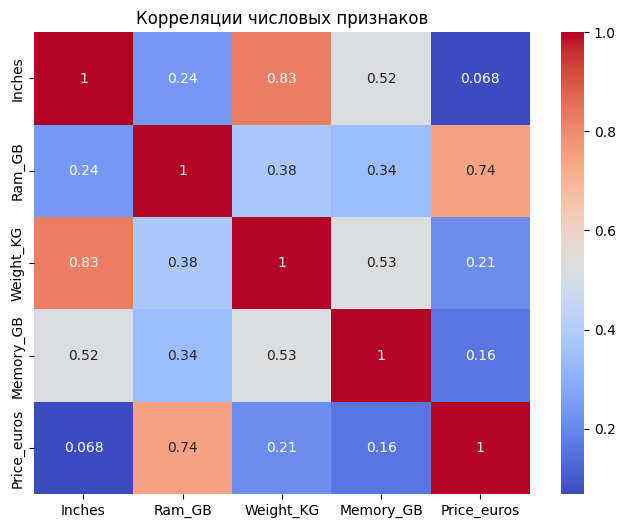

In [52]:
corr = data[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляции числовых признаков')
plt.show()



# 2. Построение базовых регрессионных моделей.

## a. Constant (среднее значение целевого показателя)

In [53]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

y = data["Price_euros"]

y_mean = y.mean()

y_pred_const = np.full(shape=len(data), fill_value=y_mean)

mse_const = mean_squared_error(y, y_pred_const)
r2_const = r2_score(y, y_pred_const)

print("Constant")
print("  Средняя цена =", y_mean)
print("  MSE        =", mse_const)
print("  R^2        =", r2_const)

Constant
  Средняя цена = 1123.6869915579432
  MSE        = 488238.6502610951
  R^2        = 0.0


## b. ConstantByGroup (среднее значение на основе одного из показателей)

In [54]:
group_col = "TypeName"

group_mean = data.groupby(group_col)["Price_euros"].mean()

def predict_constant_by_group(data, group_col, group_mean, global_mean):

    return data[group_col].map(group_mean).fillna(global_mean)

y_pred_const_group = predict_constant_by_group(data, group_col, group_mean, y_mean)

mse_const_group = mean_squared_error(y, y_pred_const_group)
r2_const_group = r2_score(y, y_pred_const_group)

print(f"ConstantByGroup ({group_col})")
print("  MSE =", mse_const_group)
print("  R^2 =", r2_const_group)

ConstantByGroup (TypeName)
  MSE = 301242.0413294363
  R^2 = 0.38300246986111963


## c. OneParamModel (линейная регрессионная модель на базе одного выбранного показателя)


In [55]:
feature = "Cpu_GHz"

X = data[[feature]]

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred_lin = lin_reg.predict(X)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(f"OneParamModel (feature = {feature})")
print("  w0 (intercept) =", lin_reg.intercept_)
print("  w1 (coef)      =", lin_reg.coef_[0])
print("  MSE            =", mse_lin)
print("  R^2            =", r2_lin)

OneParamModel (feature = Cpu_GHz)
  w0 (intercept) = -241.84049885875424
  w1 (coef)      = 594.0247454388398
  MSE            = 397840.2126929178
  R^2            = 0.18515215360323267


# 3. Построение линейных регрессионных моделей.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

y = data["Price_euros"]

X = data.drop(columns=["Price_euros"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=97
)

numeric_features = [
    "Inches", "Ram_GB", "Memory_GB", "Weight_KG", "Cpu_GHz"
]
categorical_features = [
    "Company", "Product", "TypeName", "ScreenResolution", "Cpu",
    "Gpu", "OpSys", "Memory_type"
]

## a. Линейная регрессионная модель только на количественных признаках

### Без нормализации

In [57]:
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

linreg_num = LinearRegression()
linreg_num.fit(X_train_num, y_train)

y_pred_train_num = linreg_num.predict(X_train_num)
y_pred_test_num = linreg_num.predict(X_test_num)

mse_train_num = mean_squared_error(y_train, y_pred_train_num)
r2_train_num = r2_score(y_train, y_pred_train_num)
mse_test_num = mean_squared_error(y_test, y_pred_test_num)
r2_test_num = r2_score(y_test, y_pred_test_num)

print("Train: MSE =", mse_train_num, "R^2 =", r2_train_num)
print("Test : MSE =", mse_test_num, "R^2 =", r2_test_num)

print("\nКоэффициенты:")
for name, coef in zip(numeric_features, linreg_num.coef_):
    print(f"{name:15s}: {coef:.4f}")
print("Intercept (w0):", linreg_num.intercept_)

Train: MSE = 178867.0559506292 R^2 = 0.62041782325735
Test : MSE = 243710.84054319662 R^2 = 0.5602571671906125

Коэффициенты:
Inches         : -93.9049
Ram_GB         : 91.9469
Memory_GB      : -0.0801
Weight_KG      : 40.1635
Cpu_GHz        : 337.1841
Intercept (w0): 955.9825662737884


### С нормализацией

In [58]:
num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

num_pipeline.fit(X_train_num, y_train)

y_pred_train_num_scaled = num_pipeline.predict(X_train_num)
y_pred_test_num_scaled = num_pipeline.predict(X_test_num)

mse_train_num_scaled = mean_squared_error(y_train, y_pred_train_num_scaled)
r2_train_num_scaled = r2_score(y_train, y_pred_train_num_scaled)
mse_test_num_scaled = mean_squared_error(y_test, y_pred_test_num_scaled)
r2_test_num_scaled = r2_score(y_test, y_pred_test_num_scaled)

print("Train: MSE =", mse_train_num_scaled, "R^2 =", r2_train_num_scaled)
print("Test : MSE =", mse_test_num_scaled, "R^2 =", r2_test_num_scaled)

reg_scaled = num_pipeline.named_steps["regressor"]
scaler = num_pipeline.named_steps["scaler"]

print("\nКоэффициенты:")
for name, coef in zip(numeric_features, reg_scaled.coef_):
    print(f"{name:15s}: {coef:.4f}")
print("Intercept (w0):", reg_scaled.intercept_)

Train: MSE = 178867.05595062918 R^2 = 0.6204178232573501
Test : MSE = 243710.84054319185 R^2 = 0.5602571671906211

Коэффициенты:
Inches         : -133.3351
Ram_GB         : 480.5005
Memory_GB      : -38.8200
Weight_KG      : 27.5834
Cpu_GHz        : 169.2088
Intercept (w0): 1133.6213819577738


## b. Линейная регрессия на полном множестве признаков

### Без нормализации количественных показателей

In [59]:
preprocess_no_scale = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model_full = Pipeline(steps=[
    ("preprocess", preprocess_no_scale),
    ("regressor", LinearRegression())
])

model_full.fit(X_train, y_train)

y_pred_train_full = model_full.predict(X_train)
y_pred_test_full = model_full.predict(X_test)

mse_train_full = mean_squared_error(y_train, y_pred_train_full)
r2_train_full = r2_score(y_train, y_pred_train_full)
mse_test_full = mean_squared_error(y_test, y_pred_test_full)
r2_test_full = r2_score(y_test, y_pred_test_full)

print("Train: MSE =", mse_train_full, "R^2 =", r2_train_full)
print("Test : MSE =", mse_test_full, "R^2 =", r2_test_full)

Train: MSE = 8673.818881540701 R^2 = 0.9815928817398577
Test : MSE = 149606.83495507506 R^2 = 0.7300549566684931


### C нормализацией количественных показателей

In [60]:
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model_full_scaled = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("regressor", LinearRegression())
])

model_full_scaled.fit(X_train, y_train)

y_pred_train_full_scaled = model_full_scaled.predict(X_train)
y_pred_test_full_scaled = model_full_scaled.predict(X_test)

mse_train_full_scaled = mean_squared_error(y_train, y_pred_train_full_scaled)
r2_train_full_scaled = r2_score(y_train, y_pred_train_full_scaled)
mse_test_full_scaled = mean_squared_error(y_test, y_pred_test_full_scaled)
r2_test_full_scaled = r2_score(y_test, y_pred_test_full_scaled)

print("Train: MSE =", mse_train_full_scaled, "R^2 =", r2_train_full_scaled)
print("Test : MSE =", mse_test_full_scaled, "R^2 =", r2_test_full_scaled)

Train: MSE = 8560.592488723982 R^2 = 0.9818331647837177
Test : MSE = 155141.48415800522 R^2 = 0.7200684402144933


### Анализ весовых коэффициентов полной модели

In [61]:

preprocess = model_full_scaled.named_steps["preprocess"]
linreg_full_scaled = model_full_scaled.named_steps["regressor"]

num_feature_names = numeric_features

cat_encoder = preprocess.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

coefs = linreg_full_scaled.coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
}).sort_values("abs_coef", ascending=False)

print(coef_df.head(30))  # топ-30 по |коэффициенту|
print("Intercept (w0):", linreg_full_scaled.intercept_)

                                     feature         coef     abs_coef
679               Cpu_Intel Xeon E3-1535M V6  2133.761182  2133.761182
359                Product_Rog G752VT-GC073T  1495.457705  1495.457705
165                     Product_GS40 Phantom  1478.658873  1478.658873
349                Product_ROG G703VI-E5062T  1327.650174  1327.650174
121                   Product_EliteBook x360  1247.651438  1247.651438
448                      Product_Thinkpad X1  1198.867797  1198.867797
432                      Product_ThinkPad X1  1087.156615  1087.156615
451                    Product_Thinkpad Yoga  1085.693615  1085.693615
145  Product_G701VO-IH74K (i7-6820HK/32GB/2x -1016.415974  1016.415974
769              Gpu_Nvidia GeForce GTX 970M  -987.612768   987.612768
426                   Product_ThinkPad T460s   968.915789   968.915789
259                    Product_Latitude 5289   963.918162   963.918162
433                    Product_ThinkPad Yoga   960.681837   960.681837
355   

# 4. Применение других регрессионных моделей с использованием всех показателей.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

y = data["Price_euros"]
X = data.drop(columns=["Price_euros"])

numeric_features = ["Inches", "Ram_GB", "Memory_GB", "Weight_KG", "Cpu_GHz"]
categorical_features = [
    "Company", "Product", "TypeName", "ScreenResolution", "Cpu",
    "Gpu", "OpSys", "Memory_type"
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=97
)

## a. Полиномиальная регрессионная модель

In [63]:
degree = 2
numeric_poly = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=degree, include_bias=False))
])

preprocess_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_poly, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

alphas = [0.0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 10.0, 100.0]

results_poly = []

for alpha in alphas:
    model_poly = Pipeline(steps=[
        ("preprocess", preprocess_poly),
        ("regressor", Ridge(alpha=alpha, random_state=97))
    ])

    model_poly.fit(X_train, y_train)

    y_train_pred = model_poly.predict(X_train)
    y_test_pred  = model_poly.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train  = r2_score(y_train, y_train_pred)
    mse_test  = mean_squared_error(y_test, y_test_pred)
    r2_test   = r2_score(y_test, y_test_pred)

    results_poly.append((alpha, mse_train, r2_train, mse_test, r2_test))

print("Полиномиальная регрессия (degree =", degree, ") + Ridge")
print("alpha | MSE_train | R2_train | MSE_test | R2_test")
for alpha, mse_tr, r2_tr, mse_te, r2_te in results_poly:
    print(f"{alpha:5.2f} | {mse_tr:9.2f} | {r2_tr:8.3f} | {mse_te:9.2f} | {r2_te:8.3f}")

Полиномиальная регрессия (degree = 2 ) + Ridge
alpha | MSE_train | R2_train | MSE_test | R2_test
 0.00 |   7820.26 |    0.983 | 141725.50 |    0.744
 0.01 |   7892.12 |    0.983 | 128845.64 |    0.768
 0.10 |   8907.37 |    0.981 | 104459.90 |    0.812
 0.20 |   9966.38 |    0.979 |  99748.04 |    0.820
 0.30 |  10971.94 |    0.977 |  98259.36 |    0.823
 0.40 |  11944.13 |    0.975 |  97840.51 |    0.823
 0.50 |  12871.91 |    0.973 |  97738.88 |    0.824
 1.00 |  17082.27 |    0.964 |  99488.89 |    0.820
 1.50 |  20664.79 |    0.956 | 102234.70 |    0.816
 2.00 |  23769.84 |    0.950 | 105065.80 |    0.810
 3.00 |  28935.19 |    0.939 | 110355.68 |    0.801
 4.00 |  33131.74 |    0.930 | 114831.19 |    0.793
 5.00 |  36661.84 |    0.922 | 118837.50 |    0.786
10.00 |  48841.29 |    0.896 | 133295.86 |    0.759
100.00 |  95078.09 |    0.798 | 187395.77 |    0.662


## b. Модель на основе дерева решений

In [64]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

results = []

for max_depth in [3, 5, 7, 10, 15, None]:
    for min_samples_split in [2, 5, 10]:
        for min_samples_leaf in [1, 2, 5]:
            tree_model = Pipeline(steps=[
                ("preprocess", preprocess_tree),
                ("regressor", DecisionTreeRegressor(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=97,
                ))
            ])

            tree_model.fit(X_train, y_train)

            y_train_pred = tree_model.predict(X_train)
            y_test_pred  = tree_model.predict(X_test)

            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train  = r2_score(y_train, y_train_pred)
            mse_test  = mean_squared_error(y_test, y_test_pred)
            r2_test   = r2_score(y_test, y_test_pred)

            results.append({
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "MSE_train": mse_train,
                "R2_train": r2_train,
                "MSE_test": mse_test,
                "R2_test": r2_test,
            })

results_df = pd.DataFrame(results)

results_df.sort_values("R2_test", ascending=False).head(10)

,max_depth,min_samples_split,min_samples_leaf,MSE_train,R2_train,MSE_test,R2_test
34,10.0,10,2,46505.574927,0.901308,166368.018812,0.699812
31,10.0,5,2,41382.434410,0.912180,168405.654119,0.696135
35,10.0,10,5,53383.719534,0.886712,168961.915787,0.695131
29,10.0,2,5,53383.719534,0.886712,168961.915787,0.695131
32,10.0,5,5,53383.719534,0.886712,168961.915787,0.695131
40,15.0,5,2,24931.763550,0.947091,169451.622778,0.694248
51,NaN,10,1,13861.271902,0.970584,169505.055172,0.694151
28,10.0,2,2,38301.422559,0.918719,170812.049177,0.691793
41,15.0,5,5,48803.126467,0.896433,170857.819257,0.691710
38,15.0,2,5,48803.126467,0.896433,170857.819257,0.691710


## c. Модель на основе случайного леса

In [65]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

results_forest = []

for n_estimators in [100, 200, 300]:
    for max_depth in [None, 5, 10, 20]:
        for min_samples_leaf in [1, 2, 5]:
            forest_model = Pipeline(steps=[
                ("preprocess", preprocess_tree),
                ("regressor", RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    n_jobs=-1,
                    random_state=97,
                ))
            ])

            forest_model.fit(X_train, y_train)

            y_train_pred = forest_model.predict(X_train)
            y_test_pred  = forest_model.predict(X_test)

            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train  = r2_score(y_train, y_train_pred)
            mse_test  = mean_squared_error(y_test, y_test_pred)
            r2_test   = r2_score(y_test, y_test_pred)

            results_forest.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "MSE_train": mse_train,
                "R2_train": r2_train,
                "MSE_test": mse_test,
                "R2_test": r2_test,
            })

results_forest_df = pd.DataFrame(results_forest)

results_forest_df.sort_values("R2_test", ascending=False).head(10)

,n_estimators,max_depth,min_samples_leaf,MSE_train,R2_train,MSE_test,R2_test
1,100,NaN,2,21483.743313,0.954408,129490.981244,0.766351
10,100,20.0,2,21593.914206,0.954175,130879.002792,0.763847
13,200,NaN,2,21274.544472,0.954852,131934.527912,0.761942
25,300,NaN,2,21159.146860,0.955097,132341.220003,0.761208
22,200,20.0,2,21457.235507,0.954465,132947.869631,0.760114
34,300,20.0,2,21349.391525,0.954693,133316.039484,0.759449
7,100,10.0,2,31767.477238,0.932585,138067.073062,0.750877
12,200,NaN,1,9900.647918,0.978989,138756.694646,0.749633
0,100,NaN,1,10146.661278,0.978467,139376.170945,0.748515
24,300,NaN,1,9719.550682,0.979374,139411.413860,0.748451


# 5. Сопоставление оценок важности показателей для разных моделей.

In [66]:
alpha = 0.5

model_full_scaled_poly = Pipeline(steps=[
    ("preprocess", preprocess_poly),
    ("regressor", Ridge(alpha=alpha, random_state=42))
])

model_full_scaled_poly.fit(X_train, y_train)

preprocess = model_full_scaled_poly.named_steps["preprocess"]
ridge = model_full_scaled_poly.named_steps["regressor"]

num_pipeline = preprocess.named_transformers_["num"]
poly = num_pipeline.named_steps["poly"]
num_feature_names = poly.get_feature_names_out(numeric_features)

cat_encoder = preprocess.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

coef_df_ridge = (
    pd.DataFrame({
        "feature": all_feature_names,
        "coef": ridge.coef_,
    })
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

coef_df_ridge.head(20)

,feature,coef,abs_coef
694,Cpu_Intel Xeon E3-1535M V6,691.528691,691.528691
136,Product_EliteBook x360,684.527343,684.527343
463,Product_Thinkpad X1,662.755895,662.755895
112,Product_Blade Pro,618.417811,618.417811
447,Product_ThinkPad X1,595.912342,595.912342
693,Cpu_Intel Xeon E3-1535M V5,595.869444,595.869444
550,Product_Zbook 17,595.869444,595.869444
160,Product_G701VO-IH74K (i7-6820HK/32GB/2x,-575.059001,575.059001
775,Gpu_Nvidia GeForce GTX 1080,573.476088,573.476088
774,Gpu_Nvidia GeForce GTX 1070M,572.018705,572.018705


In [67]:
best_row = results_df.sort_values("R2_test", ascending=False).iloc[0]
best_max_depth = int(best_row["max_depth"])
best_min_samples_split = int(best_row["min_samples_split"])
best_min_samples_leaf = int(best_row["min_samples_leaf"])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

best_tree_model = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("regressor", DecisionTreeRegressor(
        max_depth=best_max_depth,
        min_samples_split=best_min_samples_split,
        min_samples_leaf=best_min_samples_leaf,
        random_state=97
    ))
])

best_tree_model.fit(X_train, y_train)

tree = best_tree_model.named_steps["regressor"]
preprocess_tree = best_tree_model.named_steps["preprocess"]

cat_encoder = preprocess_tree.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names_tree = numeric_features + list(cat_feature_names)

fi_tree = (
    pd.DataFrame({
        "feature": all_feature_names_tree,
        "importance": tree.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

fi_tree.head(20)

,feature,importance
1,Ram_GB,0.658435
4,Cpu_GHz,0.058291
555,TypeName_Notebook,0.055884
3,Weight_KG,0.041664
0,Inches,0.028103
557,TypeName_Workstation,0.021576
797,Memory_type_SSD,0.016960
758,Gpu_Nvidia GeForce GTX 1070,0.015656
2,Memory_GB,0.012434
97,Product_Blade Pro,0.009367


In [68]:
best_row_forest = results_forest_df.sort_values("R2_test", ascending=False).iloc[0]

best_forest_model = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("regressor", RandomForestRegressor(
        n_estimators=int(best_row_forest["n_estimators"]),
        max_depth=None if pd.isna(best_row_forest["max_depth"]) else int(best_row_forest["max_depth"]),
        min_samples_leaf=int(best_row_forest["min_samples_leaf"]),
        n_jobs=-1,
        random_state=97,
    ))
])

best_forest_model.fit(X_train, y_train)

forest = best_forest_model.named_steps["regressor"]
preprocess_tree = best_forest_model.named_steps["preprocess"]

cat_encoder = preprocess_tree.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names_forest = numeric_features + list(cat_feature_names)

fi_forest = (
    pd.DataFrame({
        "feature": all_feature_names_forest,
        "importance": forest.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

fi_forest.head(20)

,feature,importance
1,Ram_GB,0.591874
3,Weight_KG,0.103613
4,Cpu_GHz,0.060357
555,TypeName_Notebook,0.038162
557,TypeName_Workstation,0.022193
0,Inches,0.019366
2,Memory_GB,0.015640
797,Memory_type_SSD,0.012480
758,Gpu_Nvidia GeForce GTX 1070,0.009209
119,Product_EliteBook 850,0.005221
